# **Decifrando Lisboa: O que os Dados Revelam sobre o Alojamento Local na Capital**
### Explorando a dinâmica e os padrões do mercado de hospedagem em Lisboa com dados do Airbnb.
O estudo procura trazer transparência a um mercado saturado, auxiliando turistas, anfitriões e analistas.

Fonte dos dados: https://insideairbnb.com/get-the-data/

In [71]:
# Bibliotecas

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

In [72]:
# Lendo o arquivo 

df = pd.read_csv('listings_Lisboa.csv')
df.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,6499,Belém 1 Bedroom Historical Apartment,14455,Bruno,Lisboa,Belm,38.69750,-9.19768,Entire home/apt,87.0,3,95,2025-09-03,0.71,1,283,19,NaN
1,25659,Heart of Alfama - Le cœur d'Alfama (3 people),107347,Ellie,Lisboa,Santa Maria Maior,38.71241,-9.12706,Entire home/apt,92.0,2,223,2025-09-18,1.60,1,324,10,56539/AL.
2,29396,Alfama Hill - Boutique apartment,126415,Mónica,Lisboa,Santa Maria Maior,38.71156,-9.12987,Entire home/apt,77.0,3,433,2025-09-11,2.67,1,287,32,28737/AL


In [73]:
# Informações gerais 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25449 entries, 0 to 25448
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              25449 non-null  int64  
 1   name                            25449 non-null  object 
 2   host_id                         25449 non-null  int64  
 3   host_name                       25447 non-null  object 
 4   neighbourhood_group             25449 non-null  object 
 5   neighbourhood                   25449 non-null  object 
 6   latitude                        25449 non-null  float64
 7   longitude                       25449 non-null  float64
 8   room_type                       25449 non-null  object 
 9   price                           21870 non-null  float64
 10  minimum_nights                  25449 non-null  int64  
 11  number_of_reviews               25449 non-null  int64  
 12  last_review                     

In [74]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,2.544900e+04,2.544900e+04,25449.000000,25449.000000,21870.000000,25449.000000,25449.000000,22255.000000,25449.000000,25449.000000,25449.000000
mean,6.052322e+17,2.287182e+08,38.762926,-9.207847,248.116049,4.719989,69.289206,1.566873,25.998075,217.148061,13.638257
std,5.914290e+17,2.214487e+08,0.114548,0.112146,1812.958718,16.810821,110.598085,1.551474,64.004266,129.336846,18.592469
min,6.499000e+03,1.445500e+04,38.675790,-9.486970,9.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,2.635673e+07,2.868791e+07,38.711030,-9.287910,75.000000,1.000000,3.000000,0.390000,1.000000,90.000000,0.000000
50%,6.598273e+17,1.462857e+08,38.719520,-9.147947,110.000000,2.000000,21.000000,1.090000,5.000000,263.000000,5.000000
75%,1.182779e+18,4.389003e+08,38.746920,-9.135128,167.000000,3.000000,86.000000,2.320000,16.000000,332.000000,21.000000
max,1.513766e+18,7.196566e+08,39.304030,-8.862100,86733.000000,1000.000000,1787.000000,29.720000,391.000000,365.000000,329.000000


In [75]:
# Alterando a coluda 'last_review' para datatime 

df['last_review'] = pd.to_datetime(df['last_review'])

In [76]:
# Verificando duplicados em 'id'

df['id'].duplicated().sum()


0

In [77]:
# Verificando duplicados em 'host_id'

df['host_id'].duplicated().sum()

15583

### **Comentário**

Na coluna **'host_id'** verificou-se que há 15583 hosts que possuem mais de um alojamento anunciado, o que é normal. Muitas vezes o host pode ter mais de um tipo de anúncio, uma vez que o mesmo host pode ter mais de uma casa ou quarto para arrendar. 

É importante notar que a coluna **'id'** não possui duplicados, já que isso se trata do id exclusivo para cada anúncio. 

A coluna **'last_review'** foi alterada para o tipo datetime, já que se trata de uma data. 

# **Regiões**

## **Identificação das Regiões**

In [78]:
# Quantidade de distritos
df['neighbourhood_group'].unique().tolist()


['Lisboa',
 'Cascais',
 'Vila Franca De Xira',
 'Sintra',
 'Oeiras',
 'Mafra',
 'Torres Vedras',
 'Lourinh',
 'Cadaval',
 'Amadora',
 'Alenquer',
 'Arruda Dos Vinhos',
 'Odivelas',
 'Loures',
 'Azambuja',
 'Sobral De Monte Agrao']

In [79]:
df['neighbourhood_group'].nunique()

16

In [80]:
# Quantidade de anúncios por região

listings_region = df.groupby('neighbourhood_group')['id'].count().reset_index().sort_values(by='id', ascending=False)
listings_region.columns = ['region', 'qtd_listings']
listings_region

,region,qtd_listings
6,Lisboa,17428
5,Cascais,2437
12,Sintra,1680
9,Mafra,1335
8,Lourinh,573
11,Oeiras,524
14,Torres Vedras,406
7,Loures,305
1,Amadora,270
10,Odivelas,165


In [81]:
# Criando o Gráfico de Barras
fig = px.bar(
    listings_region,
    x='region',
    y='qtd_listings',
    color='region',
    color_discrete_sequence=px.colors.qualitative.Pastel, # Paleta de cores suaves
    text_auto=True # Rótulos de dados nas barras
)

# Ajustando o Layout e a Estética
fig.update_layout(
    # Título centralizado e padronizado
    title=dict(
        text='Volume de Anúncios: Comparativo Regional', 
        font=dict(size=18, color='black'),
        x=0.5 
    ),
    xaxis_title='Região',
    yaxis_title='Quantidade de Anúncios',
    
    # O estilo visual "Clean"
    plot_bgcolor="#ffffff",      # Fundo da área do gráfico
    paper_bgcolor="#ffffff",     # Fundo geral
    font=dict(color="#333333"),  # Cor da fonte (cinza escuro)
    
    showlegend=False,            # Remove a legenda lateral
    margin=dict(t=60, b=40, l=40, r=20)
)

# 3. Ajustando as linhas de grade (Estilo whitegrid)
fig.update_xaxes(showgrid=False) 
fig.update_yaxes(gridcolor="#e5e5e5", gridwidth=1) 

# Exibindo o gráfico
fig.show()

## **Média de preços por região**

### **Outliers**

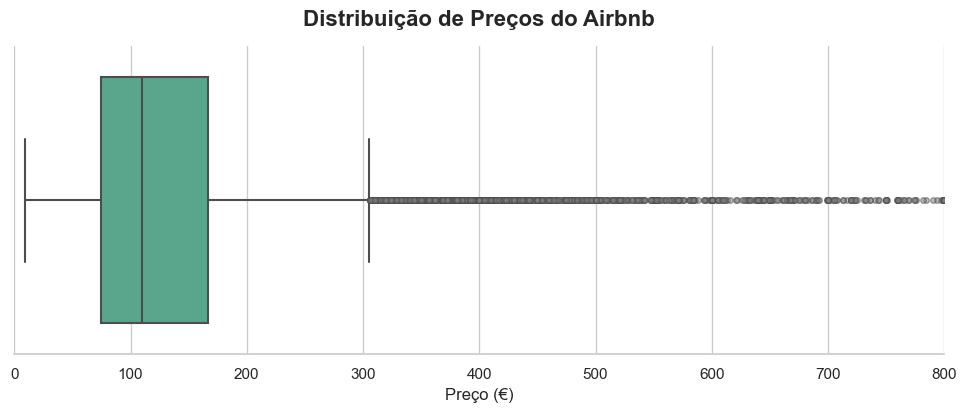

In [82]:
# 1. Define o estilo de fundo limpo com linhas de grade
sns.set_theme(style="whitegrid")


plt.figure(figsize=(12, 4))

# 3. Plota o boxplot com cores e espessuras customizadas
sns.boxplot(
    x=df['price'], 
    color="#4CB391",       # Cor verde-água elegante
    linewidth=1.5,         # Espessura da linha
    flierprops={           # Customiza as bolinhas dos outliers
        "marker": "o", 
        "markerfacecolor": "gray", 
        "markersize": 4, 
        "alpha": 0.5       # Deixa os outliers meio transparentes
    }
)

# 4. Textos, Títulos e Eixos
plt.title("Distribuição de Preços do Airbnb", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Preço (€)", fontsize=12)

# 5. Dá um zoom no gráfico limitando o eixo X
# (Ajuste o '800' para mais ou para menos dependendo de como quiser focar)
plt.xlim(0, 800) 

# 6. Remove as bordas quadradas ao redor do gráfico para um visual mais "clean"
sns.despine(left=True)

# Exibe o gráfico
plt.show()

In [83]:
# Remove os Outliers

# 1. Encontra o Q1 (25%) e o Q3 (75%) dos preços
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)

# 2. Calcula o IQR (a diferença entre Q3 e Q1)
iqr = q3 - q1

# 3. Definir a linha de corte (o limite máximo aceitável)
# A regra matemática é: Q3 + 1.5 vezes o valor do IQR
limite_superior = q3 + 1.5 * iqr

# 4. Criar o DataFrame limpo, filtrando apenas quem está abaixo desse limite
df_limpo = df[df['price'] <= limite_superior]


print(f"O limite máximo considerado normal foi de: {limite_superior} €")
print(f"Quantidade de linhas antes da limpeza: {df.shape[0]}")
print(f"Quantidade de linhas depois da limpeza: {df_limpo.shape[0]}")

O limite máximo considerado normal foi de: 305.0 €
Quantidade de linhas antes da limpeza: 25449
Quantidade de linhas depois da limpeza: 20283


In [84]:
# Média de preços por região

price_region = df_limpo.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False).reset_index()
price_region 

,neighbourhood_group,price
0,Azambuja,132.777778
1,Mafra,124.457627
2,Lourinh,121.985714
3,Cascais,121.937466
4,Alenquer,121.612500
5,Cadaval,118.913793
6,Lisboa,118.474353
7,Sintra,110.726062
8,Torres Vedras,110.125000
9,Sobral De Monte Agrao,104.105263


## **Comentário**

No total foram identificadas 16 regiões/distritos na base de dados. O distrito que mais possui anúncios é Lisboa, seguido de Cascais, Sintra e Mafra. 

Após a identificação de outliers nos preços, podemos afirmar que a massa principal do mercado opera na faixa de 80 até 180 euros. Embora esses valores sejam os mais habtuais, ainda pode-se encontrar muitos alojamentos com valores até 305 euros por noite. Valores acima de 305 euros já podem se considerados outliers, como indicados no gráfico acima. 



# **Lisboa** 

In [85]:
# Filtra o df apenas com a região de lisboa  

df_lisboa = df[df['neighbourhood_group'] == 'Lisboa']
df_lisboa.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,6499,Belém 1 Bedroom Historical Apartment,14455,Bruno,Lisboa,Belm,38.69750,-9.19768,Entire home/apt,87.0,3,95,2025-09-03,0.71,1,283,19,NaN
1,25659,Heart of Alfama - Le cœur d'Alfama (3 people),107347,Ellie,Lisboa,Santa Maria Maior,38.71241,-9.12706,Entire home/apt,92.0,2,223,2025-09-18,1.60,1,324,10,56539/AL.
2,29396,Alfama Hill - Boutique apartment,126415,Mónica,Lisboa,Santa Maria Maior,38.71156,-9.12987,Entire home/apt,77.0,3,433,2025-09-11,2.67,1,287,32,28737/AL


### **Identificação dos bairros**

In [86]:
# Quantidade de anúncios por bairro

listings_neighbourhood = df_lisboa['neighbourhood'].value_counts().reset_index()
listings_neighbourhood

,neighbourhood,count
0,Santa Maria Maior,3482
1,Misericrdia,2630
2,Arroios,2234
3,Santo Antnio,1545
4,So Vicente,1263
5,Estrela,1027
6,Avenidas Novas,884
7,Penha de Frana,618
8,Campo de Ourique,467
9,Areeiro,447


In [87]:
top_10_neighbourhood = listings_neighbourhood.head(10)
top_10_neighbourhood 

,neighbourhood,count
0,Santa Maria Maior,3482
1,Misericrdia,2630
2,Arroios,2234
3,Santo Antnio,1545
4,So Vicente,1263
5,Estrela,1027
6,Avenidas Novas,884
7,Penha de Frana,618
8,Campo de Ourique,467
9,Areeiro,447


In [88]:
# Criando o Gráfico de Barras
fig = px.bar(
    top_10_neighbourhood,
    x='neighbourhood',
    y='count',
    color='neighbourhood',
    # Substituímos o 'palette' pela paleta de cores suaves nativa do Plotly
    color_discrete_sequence=px.colors.qualitative.Pastel, 
    text_auto=True # Dica extra: Coloca o valor exato em cima de cada barra!
)

# Ajustando o Layout e a Estética
fig.update_layout(
    # Título mais limpo e centralizado (x=0.5)
    title=dict(
        text='Top 10 Bairros de Lisboa com mais anúncios', 
        font=dict(size=18, color='black'),
        x=0.5 
    ),
    xaxis_title='Bairros',
    yaxis_title='Quantidade de Anúncios',
    
    # Estilo visual 
    plot_bgcolor="#ffffff",      # Fundo da área do gráfico branco puro
    paper_bgcolor="#ffffff",     # Fundo geral branco
    font=dict(color="#333333"),  # Fonte cinza escuro 
    
    
    showlegend=False, # Remove a legenda lateral 
    margin=dict(t=60, b=40, l=40, r=20) # Dá um respiro nas margens do gráfico
)

# Ajustando as linhas de grade 
fig.update_xaxes(showgrid=False) # Remove linhas verticais (poluem a visão em gráficos de barra)
fig.update_yaxes(gridcolor="#e5e5e5", gridwidth=1) # Linhas horizontais em cinza bem clarinho

# Exibindo o gráfico
fig.show()

#### **Comentário**

Os alojamentos Airbnb foram encontrados em 24 bairros de Lisboa. Sendo eles: 
•	Santa Maria Maior	
•	Misericórdia	
•	Arroios	
•	Santo António	
•	São Vicente	
•	Estrela	
•	Avenidas Novas	
•	Penha de Frana	
•	Campo de Ourique	
•	Areeiro
•	Alvalade	
•	Parque das Nações	
•	Alcântara	
•	Campolide	
•	Belém	
•	Ajuda	
•	Olivais	
•	São Domingos de Benfica	
•	Lumiar	
•	Marvila	
•	Beato	
•	Benfica	
•	Santa Clara	
•	Carnide

**1. Hiperconcentração no Centro Histórico (O Núcleo Turístico)**
Liderança Isolada: Bairros como Santa Maria Maior (que engloba Baixa, Alfama, Castelo) e Misericórdia (Bairro Alto, Chiado, Cais do Sodré) dominam sistematicamente o topo destes gráficos.

**O Motivo:** Isto reflete a preferência esmagadora dos visitantes por estadias walkable (onde se faz tudo a pé) e pela proximidade imediata a monumentos, miradouros e vida noturna. O volume nestas duas freguesias costuma descolar abruptamente do resto da cidade.

**2. O Efeito de Expansão (Spillover)**
Logo a seguir ao núcleo histórico, surgem bairros adjacentes como Arroios, Santo António (Avenida da Liberdade/Príncipe Real) e São Vicente (Graça).

**O Motivo:** À medida que o centro histórico fica saturado (seja por preços mais altos ou por zonas de contenção aplicadas pela Câmara Municipal), tanto os investidores como os turistas "transbordam" para as fronteiras imediatas. Arroios, por exemplo, tem uma enorme densidade de alojamentos devido à excelente rede de metro (Linha Verde) e à reabilitação urbana dos últimos anos.

**3. Diversificação do Perfil de Turista**
A presença de áreas como Avenidas Novas ou Estrela no Top 10 aponta para uma segmentação de mercado.

**O Motivo:** Enquanto o turista de fim de semana prefere o centro histórico, as Avenidas Novas e a Estrela atraem frequentemente viajantes corporativos, famílias, ou nómadas digitais. São públicos que valorizam prédios mais recentes (com elevador e garagem), ruas mais amplas e maior tranquilidade, estando dispostos a ficar a 15 minutos do centro.

**4. A Regra de Pareto e a Pressão Habitacional**
A distribuição em Lisboa obedece claramente a uma lógica de Pareto (80/20): uma minoria dos bairros lisboetas concentra a grande maioria dos alojamentos de toda a cidade.

**Impacto Económico-Social:** Este gráfico ilustra o mapa térmico da pressão turística. A elevada densidade nos bairros do topo é o principal motor do aumento do custo por metro quadrado para compra e arrendamento de longa duração, uma vez que a habitação tradicional concorre diretamente com a rentabilidade diária do turismo nestas zonas.

O gráfico não mostra apenas "onde há mais turistas". Funciona como um raio-X perfeito à forma como o turismo direciona o investimento imobiliário na cidade, desenhando um padrão claro de "centro vs. periferia" dentro do próprio concelho de Lisboa.


## **Média de preços por bairros em Lisboa**

In [89]:
price_lisboa = df_lisboa.groupby('neighbourhood')['price'].mean().reset_index().sort_values(by='price', ascending=False)
price_lisboa

,neighbourhood,price
21,Santo Antnio,897.534796
20,Santa Maria Maior,357.412620
4,Arroios,184.118684
17,Parque das Naes,180.648464
15,Misericrdia,169.482290
12,Estrela,164.831169
14,Marvila,163.302521
9,Campo de Ourique,149.093264
23,So Vicente,146.847028
1,Alcntara,143.946043


### **Outliers**

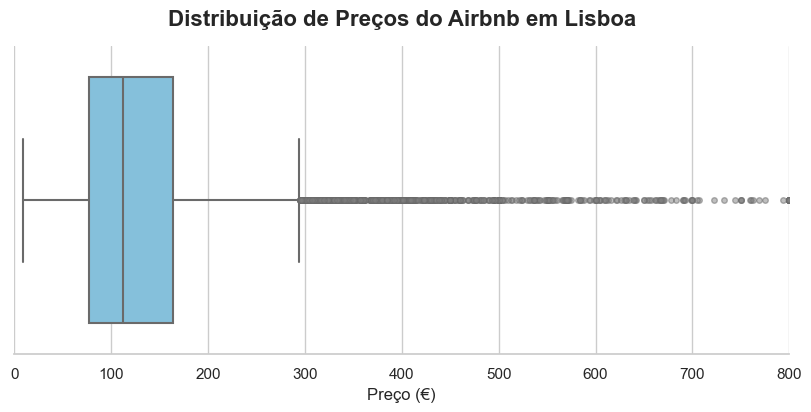

In [90]:
# 1. Define o estilo de fundo limpo com linhas de grade
sns.set_theme(style="whitegrid")


plt.figure(figsize=(10, 4))

# 3. Plota o boxplot com cores e espessuras customizadas
sns.boxplot(
    x=df_lisboa['price'], 
    color="#77C5E9",       # Cor verde-água elegante
    linewidth=1.5,         # Espessura da linha
    flierprops={           # Customiza as bolinhas dos outliers
        "marker": "o", 
        "markerfacecolor": "gray", 
        "markersize": 4, 
        "alpha": 0.5       # Deixa os outliers meio transparentes
    }
)

# 4. Textos, Títulos e Eixos
plt.title("Distribuição de Preços do Airbnb em Lisboa", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Preço (€)", fontsize=12)

# 5. Dá um zoom no gráfico limitando o eixo X
# (Ajuste o '800' para mais ou para menos dependendo de como quiser focar)
plt.xlim(0, 800) 

# 6. Remove as bordas quadradas ao redor do gráfico para um visual mais "clean"
sns.despine(left=True)

# Exibe o gráfico
plt.show()

In [91]:
# Remove os Outliers

# 1. Encontra o Q1 (25%) e o Q3 (75%) dos preços
q1 = df_lisboa['price'].quantile(0.25)
q3 = df_lisboa['price'].quantile(0.75)

# 2. Calcula o IQR (a diferença entre Q3 e Q1)
iqr = q3 - q1

# 3. Definir a linha de corte (o limite máximo aceitável)
# A regra matemática é: Q3 + 1.5 vezes o valor do IQR
limite_superior = q3 + 1.5 * iqr

# 4. Criar o DataFrame limpo, filtrando apenas quem está abaixo desse limite
df_lisboa_limpo = df_lisboa[df_lisboa['price'] <= limite_superior]


print(f"O limite máximo considerado normal foi de: {limite_superior} €")
print(f"Quantidade de linhas antes da limpeza: {df.shape[0]}")
print(f"Quantidade de linhas depois da limpeza: {df_lisboa_limpo.shape[0]}")

O limite máximo considerado normal foi de: 294.5 €
Quantidade de linhas antes da limpeza: 25449
Quantidade de linhas depois da limpeza: 14095


## **Mapa Interativo de Calor (Geolocalização)**

In [92]:
# Criando o Mapa Interativo
fig = px.scatter_mapbox(
    df_lisboa_limpo, 
    lat="latitude", 
    lon="longitude", 
    color="price",           # Cor do ponto varia conforme o preço
    size="price",            # Tamanho do ponto varia conforme o preço
    color_continuous_scale=px.colors.sequential.YlOrRd, # Escala do Amarelo ao Vermelho
    size_max=10,             # Tamanho máximo dos pontos
    zoom=11,                 # Nível de zoom inicial sobre Lisboa
    hover_name="neighbourhood", # Mostra o bairro ao passar o mouse
    hover_data=["room_type", "price"], # Informações extras no hover
    title="Distribuição Geográfica de Preços em Lisboa"
)

# Configurando o estilo do mapa (usando estilo aberto que não pede Token)
fig.update_layout(
    mapbox_style="carto-positron", 
    margin={"r":0,"t":50,"l":0,"b":0},
    title_x=0.5
)

fig.show()

### **Comentário**



**1. O Mercado Padrão (80€ a 180€)**

A análise à distribuição de preços revela que o "coração" do alojamento local em Lisboa — ou seja, onde se concentra a grande maioria da oferta típica (quartos inteiros, estúdios e apartamentos T1/T2 para estadias de curta duração) — situa-se na faixa dos 80€ aos 180€ por noite. Este é o valor diário considerado normal para a esmagadora maioria dos turistas que visitam a capital, refletindo o custo base de estadia nas freguesias centrais e circundantes.

**2. O Limite do "Aceitável" (180€ a 300€)**
Apesar de o padrão se fixar até aos 180€, o mercado apresenta uma elasticidade natural até à faixa dos 300€. Valores neste intervalo não são considerados anómalos. Refletem, na verdade, variações normais de mercado ditadas por:

- Tipologia: Apartamentos de maior dimensão (T3/T4) preparados para famílias ou grupos.
- Localização Premium: Propriedades em cima do rio ou em pleno centro histórico (ex: Chiado, Baixa) com vistas exclusivas.
- Sazonalidade: Preços de época alta (verão) ou eventos de grande dimensão (ex: Web Summit, festivais).

**3. A Zona de Outliers (Acima de 300€)**
Qualquer valor que ultrapasse a barreira dos 300€ por noite foi classificado estatisticamente como um outlier neste estudo. É importante notar que estes valores não são necessariamente "erros" de introdução de dados; eles representam o mercado de luxo ou de nicho (como palacetes, moradias exclusivas com piscina ou penthouses). No entanto, para o propósito desta análise — que visa entender o comportamento do mercado de turismo de massas e o impacto habitacional comum —, estes valores foram removidos, pois distorcem drasticamente as médias e não refletem o alojamento típico lisboeta.


## **Tipo de acomodação**

### **Proporção Geral: A maioria aluga o apartamento inteiro (Entire home/apt) ou apenas um quarto (Private room)?**

In [93]:
# Tipos de alojamentos 
df_lisboa['room_type'].unique()

array(['Entire home/apt', 'Private room', 'Shared room', 'Hotel room'],
      dtype=object)

In [94]:
# Tabela pivot 

room_type_pivot = pd.pivot_table(
    data=df_lisboa,
    index='neighbourhood',    # Eixo y
    columns='room_type',     # Eixo x
    values='id',             # Interior da tabela
    aggfunc='count',         # Conta os id 
    fill_value=0          # Preenche com 0 os locais onde não há anúncios daquele tipo
)

# Adiciona uma coluna de "Total" para ver qual bairro tem mais imóveis no geral
room_type_pivot['Total'] = room_type_pivot.sum(axis=1)

# Ordenando a tabela para mostrar os bairros com mais anúncios no topo
room_type_pivot = room_type_pivot.sort_values(by='Total', ascending=False)

# Exibindo o resultado
display(room_type_pivot)

room_type,Entire home/apt,Hotel room,Private room,Shared room,Total
neighbourhood,,,,,
Santa Maria Maior,3041,48,374,19,3482
Misericrdia,2187,31,408,4,2630
Arroios,1233,22,958,21,2234
Santo Antnio,1131,38,370,6,1545
So Vicente,1083,2,177,1,1263
Estrela,864,1,161,1,1027
Avenidas Novas,421,21,438,4,884
Penha de Frana,367,0,251,0,618
Campo de Ourique,374,0,91,2,467


### **Preço por Tipo: Qual é a diferença real na média de preço de um apartamento inteiro comparado a um quarto privado dentro do seu "Top 10 Bairros"?**

In [95]:
# Seleciona os top 10 bairros sem os outliers de preço
#  
top_10_clean = df_lisboa_limpo['neighbourhood'].value_counts().reset_index()
top_10_clean = top_10_clean.head(10)
top_10_clean

,neighbourhood,count
0,Santa Maria Maior,2920
1,Misericrdia,2271
2,Arroios,1620
3,Santo Antnio,1195
4,So Vicente,1102
5,Estrela,874
6,Avenidas Novas,648
7,Penha de Frana,466
8,Campo de Ourique,372
9,Areeiro,290


In [96]:
# Extrair os nomes dos 10 bairros e transformar em uma lista do Python

lista_bairros_populares = top_10_clean['neighbourhood'].tolist()

# Filtrar o DataFrame principal (limpo) para manter APENAS as linhas que estão nessa lista
df_top_10_completo = df_lisboa_limpo[df_lisboa_limpo['neighbourhood'].isin(lista_bairros_populares)]

# Verificando se funcionou
print(f"Bairros no novo DataFrame: {df_top_10_completo['neighbourhood'].nunique()}")


Bairros no novo DataFrame: 10


In [97]:
# A Tabela Dinâmica
pivot_prices = pd.pivot_table(
    data=df_top_10_completo,
    index='neighbourhood',
    columns='room_type',
    values='price',
    aggfunc='mean'
)

#Tratando os valores vazios (NaN)
# Vamos trocar esses NaN por um traço '-' para a tabela ficar com cara de relatório profissional.
pivot_prices = pivot_prices.fillna('-')

# 3. Exibindo a tabela formatada
display(pivot_prices)

room_type,Entire home/apt,Hotel room,Private room,Shared room
neighbourhood,,,,
Areeiro,124.634921,-,59.828221,21.0
Arroios,126.750538,50.0,57.787202,31.235294
Avenidas Novas,134.823699,76.842105,64.501792,25.75
Campo de Ourique,125.088889,-,62.122807,-
Estrela,122.418667,-,70.959350,26.0
Misericrdia,141.406462,236.857143,84.692082,56.0
Penha de Frana,114.397993,-,51.508982,-
Santa Maria Maior,142.995750,119.619048,94.606164,52.421053
Santo Antnio,145.306250,136.428571,68.788288,33.333333


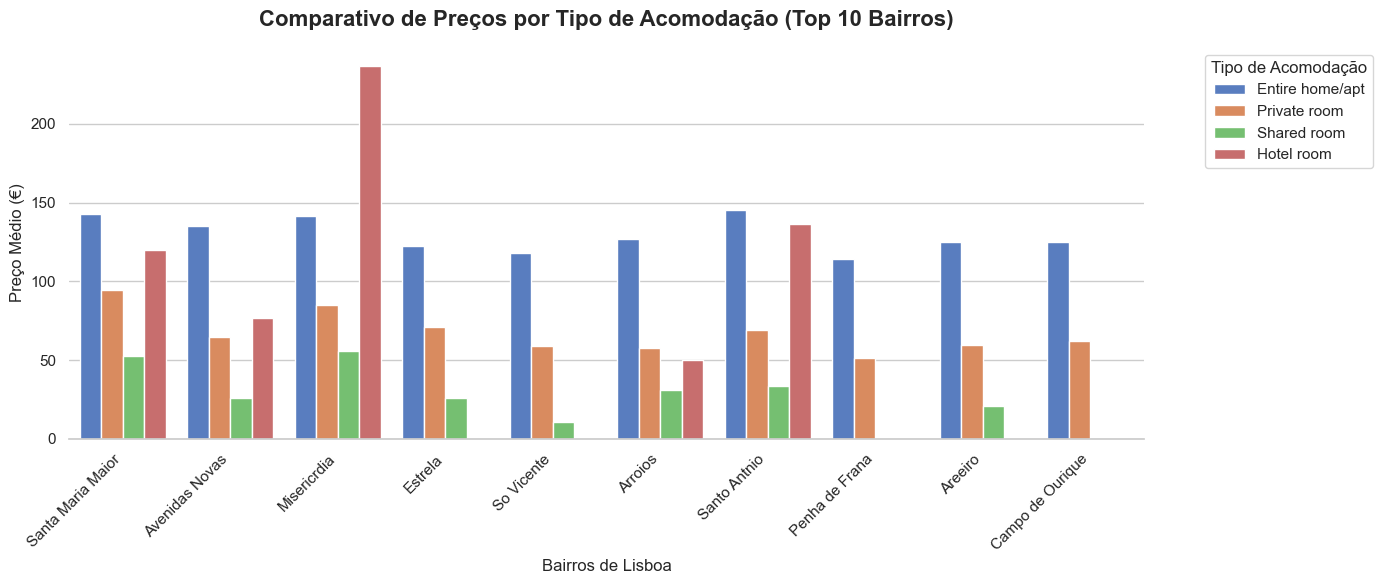

In [98]:
# Configurando o tamanho e o estilo
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Criando o gráfico de barras agrupadas
sns.barplot(
    data=df_top_10_completo, 
    x='neighbourhood', 
    y='price', 
    hue='room_type',       # Separa as cores por tipo.
    errorbar=None,         # Remove as barrinhas pretas de erro para um visual mais limpo
    palette='muted'        # Paleta de cores 
)

# Ajustes estéticos
plt.title('Comparativo de Preços por Tipo de Acomodação (Top 10 Bairros)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Bairros de Lisboa', fontsize=12)
plt.ylabel('Preço Médio (€)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Inclina os nomes dos bairros para não encavalarem
sns.despine(left=True)

# Move a legenda para um lugar que não atrapalhe os dados
plt.legend(title='Tipo de Acomodação', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### **Comentário**


Como era de se esperar, Apartamentos Inteiros (Entire home/apt - barra azul) são consistentemente a opção mais cara em todos os 10 bairros, enquanto os Quartos Privados (Private room - barra laranja) custam em média cerca de metade do valor do apartamento.

Para um turista, abrir mão da privacidade de um apartamento inteiro e alugar apenas um quarto gera uma economia de aproximadamente 60€ a 70€ por noite nas áreas mais nobres (como Santo António e Santa Maria Maior).

**A Anomalia:** A grande surpresa deste gráfico é a barra vermelha (Hotel room) no bairro da Misericórdia, que ultrapassa os 230€! Ela é absurdamente mais cara do que alugar um apartamento inteiro no mesmo bairro (que custa cerca de 140€).

**Hipótese:** Isso indica que os "quartos de hotel" listados no Airbnb nessa região específica provavelmente pertencem a hotéis-boutique de altíssimo luxo, distorcendo a média. Em contraste, no bairro de Arroios, um quarto de hotel consegue ser mais barato que um apartamento inteiro.

**Zonas Residenciais vs. Zonas Turísticas**

Note que bairros como Penha de França e Campo de Ourique só possuem barras azuis, laranjas e verdes (ou apenas azuis e laranjas). A ausência da barra vermelha indica que essas são zonas muito mais residenciais, dominadas por anfitriões comuns, sem a presença de hotéis listados na plataforma.

## **Perfil dos anfitriões**

### **Monopólio? O Airbnb em Lisboa é movido por moradores locais alugando um quarto extra, ou é dominado por empresas e investidores imobiliários ("mega-hosts") gerenciando dezenas de propriedades?**

#### **Método do cotovelo**

In [99]:
# Preparar e Agregar os Dados por Host

hosts_df = df_lisboa.groupby('host_id').agg({
    'calculated_host_listings_count': 'max', # Quantos imóveis o host tem no total
    'price': 'mean',                         # Preço médio cobrado por esse host
    'availability_365': 'mean',              # Disponibilidade média no ano
}).rename(columns={'id': 'anuncios_na_base'}).reset_index()

# Preencher possíveis valores nulos com 0 ou a média (boa prática de segurança)
hosts_df.fillna(0, inplace=True)
hosts_df


,host_id,calculated_host_listings_count,price,availability_365
0,14455,1,87.0,283.0
1,70933,1,518.0,90.0
2,107347,1,92.0,324.0
3,126415,1,77.0,287.0
4,128075,1,1250.0,308.0
...,...,...,...,...
6026,718646389,1,62.0,122.0
6027,719071066,1,177.0,349.0
6028,719094737,1,133.0,358.0
6029,719114008,2,206.0,4.0


In [100]:
# Normalização (Padronização)
# Selecionamos apenas as colunas numéricas que importam para o perfil

features = ['calculated_host_listings_count', 'price', 'availability_365']
X = hosts_df[features]

# O StandardScaler coloca tudo na mesma escala (média 0 e desvio padrão 1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [101]:
# Método do Cotovelo

print("Calculando a inércia para encontrar o K ideal...")

inercia = []
K_range = range(1, 11) # Vamos testar de 1 até 10 clusters

# Roda o modelo para cada valor de K e guarda o resultado
for k in K_range:
    kmeans_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_teste.fit(X_scaled)
    inercia.append(kmeans_teste.inertia_)

Calculando a inércia para encontrar o K ideal...


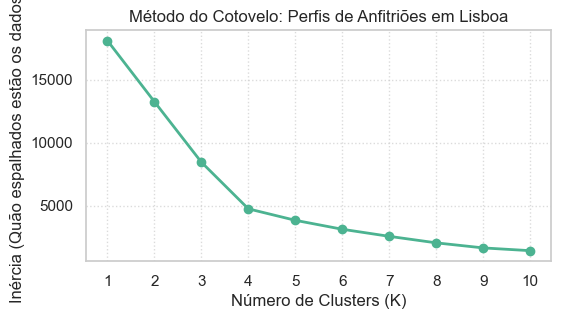

In [102]:
# Plota o gráfico
plt.figure(figsize=(6, 3))
plt.plot(K_range, inercia, marker='o', color='#4CB391', linewidth=2)
plt.title('Método do Cotovelo: Perfis de Anfitriões em Lisboa')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (Quão espalhados estão os dados)')
plt.xticks(K_range)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

#### **Clusterização - K-means**

In [103]:
# Clusterização K-Means 

# Pegamos apenas o ID do host e a quantidade de anúncios dele, e removemos as linhas duplicadas.
# Assim, se um host tem 50 anúncios, ele aparecerá apenas 1 vez nesta nova tabela.

hosts_unicos = df_lisboa[['host_id', 'calculated_host_listings_count']].drop_duplicates().copy()

In [104]:
# Configurando a Inteligência Artificial (K-Means)
# Selecionamos a coluna que o algoritmo vai usar para aprender
X = hosts_unicos[['calculated_host_listings_count']]

# Pedimos 4 grupos e travamos a aleatoriedade (random_state=42)
modelo_kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')

# Treinando e Criando os Grupos
hosts_unicos['cluster_IA'] = modelo_kmeans.fit_predict(X)


# Analisando a Decisão da Máquina

resumo_ia = (
    hosts_unicos.groupby('cluster_IA')['calculated_host_listings_count']
    .agg(
        Mínimo_de_Anúncios='min', 
        Máximo_de_Anúncios='max', 
        Total_de_Anfitriões='count', 
        Soma_Total_Anúncios='sum'
    )
    .reset_index()
    .sort_values(by='Mínimo_de_Anúncios') # Ordena do menor pro maior grupo
    .reset_index(drop=True)
)

# Visualizando a tabela final
display(resumo_ia)

,cluster_IA,Mínimo_de_Anúncios,Máximo_de_Anúncios,Total_de_Anfitriões,Soma_Total_Anúncios
0,0,1,12,5811,11804
1,1,13,64,208,4739
2,3,77,180,8,979
3,2,212,391,4,1088


### **Comentário**

**Cluster 0 (A Base: Locais e Pequenos Empreendedores)**

**Perfil:** Têm entre 1 e 12 anúncios.

**O Peso:** Representam a esmagadora maioria das pessoas (5.811 anfitriões). Eles juntos detêm 11.804 imóveis.

**Interpretação:** É aqui que moram os "locais" que alugam um quarto ou a própria casa, mas também pequenos investidores que compraram alguns apartamentos para renda.


**Cluster 1 (Gestores Profissionais Médios)**

**Perfil:** Têm entre 13 e 64 anúncios.


**O Peso:** Apenas 208 anfitriões controlam 4.739 imóveis.

**Interpretação:** Estas são claramente empresas de gestão de alojamento local. Elas não são "mega", mas têm um portfólio robusto e muito profissionalizado.


**Cluster 3 (Grandes Empresas)**

**Perfil:** Têm entre 77 e 180 anúncios.

**O Peso:** Apenas 8 empresas controlam 979 imóveis.


**Cluster 2 — Mega-Investidores**

**Perfil:** Têm entre 212 e 391 anúncios, representando o topo da distribuição.

**O Peso:** O número mais chocante da tabela. Existem apenas 4 anfitriões neste grupo, mas juntos eles monopolizam incríveis 1.088 imóveis.